# Two-tower model and the full leaderboard

Every number here comes from `reports/metrics/*.json`, written by the DVC stages
`two_tower_search` and `leaderboard` (`make experiments`). As before, models train on the
logged feed before Aug 30 and are scored on the fully observed **tune** users, ranking each
user's whole candidate list.

The two-tower model encodes a user (id + profile features) and a video (id + categories +
length) into vectors whose dot product is the score. Two training objectives are compared:

* **bce**: *will this user like this video, given it was shown?* Every logged view is an
  example. This is the same question the evaluation asks.
* **softmax**: *which video did this user like?* Positives only; the batch's other positives
  are the negatives, with the logQ correction for how often popular videos get sampled. This
  is the standard objective for retrieval in industrial two-tower systems.

One training run of the two-tower model varies by about ±0.006 NDCG@10 from seed to seed, as
much as some of the gaps compared here. So the search trains every configuration with several
seeds and selects on the seed average, and the leaderboard's `two_tower` is the average of
one model per seed (still a two-tower model: averaging dot products is one dot product of the
concatenated vectors). Both ALS and the two-tower model were tuned on these same users, so
their scores carry some selection optimism; the untouched test users give the final word.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import polars as pl

from recsys.viz import style


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dvc.yaml").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_repo_root(Path.cwd())
METRICS, FIGURES = ROOT / "reports/metrics", ROOT / "reports/figures"
report = json.loads((METRICS / "leaderboard.json").read_text(encoding="utf-8"))
search = json.loads((METRICS / "two_tower_search.json").read_text(encoding="utf-8"))
als_search = json.loads((METRICS / "als_search.json").read_text(encoding="utf-8"))
METRIC = search["select_metric"]
spread = report["seed_spread"]["two_tower"]
HIGHLIGHT = "two_tower"
style.apply_style()


def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES / f"{name}.png")
    plt.show()
    plt.close(fig)


def emphasis(model: str) -> str:
    """The highlighted model in the primary colour, everything else in recessive grey."""
    return style.PRIMARY if model == HIGHLIGHT else style.INK_MUTED

## 1. Leaderboard (tune users)

In [2]:
models = pl.DataFrame(
    [
        {
            "model": name,
            METRIC: m[METRIC],
            "ci_low": m[f"{METRIC}_ci_low"],
            "ci_high": m[f"{METRIC}_ci_high"],
            "recall_at_50": m["recall_at_50"],
            "coverage_at_10": m["coverage_at_10"],
            "popularity_pct_at_10": m["popularity_pct_at_10"],
        }
        for name, m in report["models"].items()
    ]
).sort(METRIC)
models.sort(METRIC, descending=True)

model,ndcg_at_10,ci_low,ci_high,recall_at_50,coverage_at_10,popularity_pct_at_10
str,f64,f64,f64,f64,f64,f64
"""two_tower""",0.298088,0.27067,0.325004,0.035398,0.112714,0.489802
"""als""",0.274005,0.245673,0.302142,0.029958,0.223625,0.805465
"""popularity_engagement""",0.217004,0.194855,0.240086,0.023167,0.003306,0.656027
"""category_affinity""",0.198833,0.174571,0.222588,0.020119,0.061317,0.589087
"""popularity_views""",0.183764,0.161908,0.205906,0.018544,0.003306,0.998646
"""random""",0.163518,0.14317,0.185111,0.015029,0.592125,0.503529


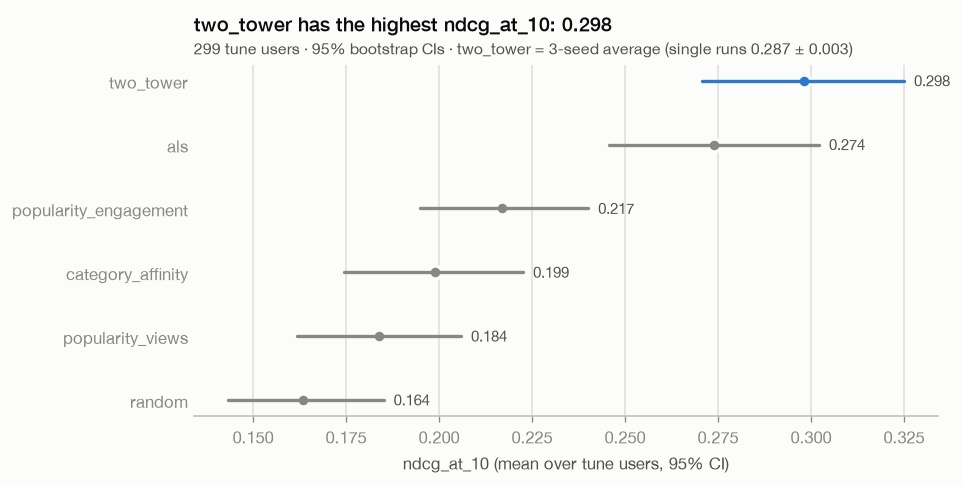

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.8))
for position, row in enumerate(models.iter_rows(named=True)):
    color = emphasis(row["model"])
    ax.plot([row["ci_low"], row["ci_high"]], [position, position], color=color, linewidth=2)
    ax.scatter([row[METRIC]], [position], s=60, color=color, edgecolors=style.SURFACE, linewidths=2)
    ax.annotate(
        f"{row[METRIC]:.3f}",
        (row["ci_high"], position),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        color=style.INK_SECONDARY,
        fontsize=9,
    )
ax.set_yticks(range(models.height), models["model"].to_list())
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.set_xlabel(f"{METRIC} (mean over tune users, 95% CI)")
leader = models.row(-1, named=True)
style.add_title(
    ax,
    f"{leader['model']} has the highest {METRIC}: {leader[METRIC]:.3f}",
    f"{report['models'][HIGHLIGHT]['users_evaluated']} tune users · 95% bootstrap CIs · "
    f"two_tower = {len(spread['seeds'])}-seed average (single runs {spread['mean']:.3f} "
    f"± {spread['sd']:.3f})",
)
save(fig, "11_leaderboard")

## 2. Paired comparisons on the same users

Each model against the strongest non-personalised model (engagement popularity) and against
ALS, the strongest Phase 2 model. Intervals cover user sampling only.

In [4]:
paired = pl.DataFrame(
    [
        {"reference": reference, "model": name, **values}
        for reference, comparison in report["paired"].items()
        for name, values in comparison["differences"].items()
    ]
)
paired.filter(pl.col("model").is_in(["category_affinity", "als", "two_tower"])).select(
    "reference", "model", "mean", "ci_low", "ci_high", "win_rate"
)

reference,model,mean,ci_low,ci_high,win_rate
str,str,f64,f64,f64,f64
"""popularity_engagement""","""category_affinity""",-0.018171,-0.034392,-0.002376,0.459866
"""popularity_engagement""","""als""",0.057,0.03125,0.082722,0.565217
"""popularity_engagement""","""two_tower""",0.081084,0.058307,0.102592,0.665552
"""als""","""category_affinity""",-0.075171,-0.101187,-0.04737,0.384615
"""als""","""two_tower""",0.024084,-0.000114,0.047481,0.563545


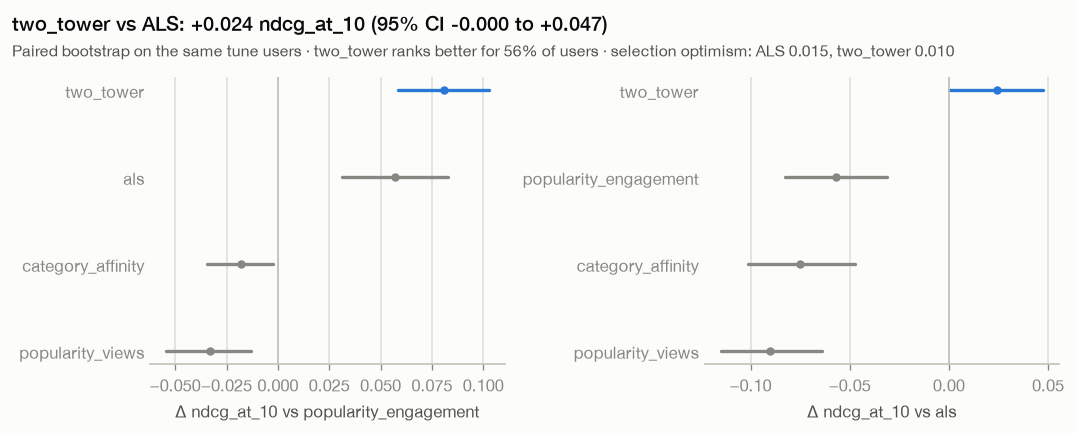

In [5]:
references = list(report["paired"])
fig, axes = plt.subplots(1, len(references), figsize=(9, 3.6))
for ax, reference in zip(axes, references, strict=True):
    rows = paired.filter((pl.col("reference") == reference) & (pl.col("model") != "random")).sort(
        "mean"
    )
    for position, row in enumerate(rows.iter_rows(named=True)):
        color = emphasis(row["model"])
        ax.plot([row["ci_low"], row["ci_high"]], [position, position], color=color, linewidth=2)
        ax.scatter(
            [row["mean"]], [position], s=50, color=color, edgecolors=style.SURFACE, linewidths=2
        )
    ax.axvline(0, color=style.BASELINE, linewidth=1)
    ax.set_yticks(range(rows.height), rows["model"].to_list())
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    ax.set_xlabel(f"Δ {METRIC} vs {reference}")
vs_als = paired.filter((pl.col("reference") == "als") & (pl.col("model") == HIGHLIGHT)).row(
    0, named=True
)
style.add_figure_title(
    fig,
    f"two_tower vs ALS: {vs_als['mean']:+.3f} {METRIC} "
    f"(95% CI {vs_als['ci_low']:+.3f} to {vs_als['ci_high']:+.3f})",
    f"Paired bootstrap on the same tune users · two_tower ranks better for "
    f"{vs_als['win_rate']:.0%} of users · selection optimism: ALS "
    f"{als_search['selection_optimism']:.3f}, two_tower {search['selection_optimism']:.3f}",
)
fig.tight_layout(rect=(0, 0, 1, style.FIGURE_TITLE_TOP))
save(fig, "12_paired_vs_references")

## 3. Training curves: which objective, how long

Every configuration was trained once per seed and scored on tune after each epoch, so the
epoch count was searched along with the loss, embedding size and (softmax only) temperature.
Curves are seed averages; the best curve per loss is coloured, with a band of ±1 standard
deviation across seeds, and the rest are grey. The two losses also get different amounts of
training per epoch (bce sees every view, softmax only the positives, about 5x fewer steps),
so this compares the two objectives as configured here, not in general.

In [6]:
trials = pl.DataFrame(
    [
        {
            "loss": trial["params"]["loss"],
            "embedding_dim": trial["params"]["embedding_dim"],
            "temperature": trial["params"]["temperature"],
            "epoch": trial["params"]["epochs"],
            "train_loss": trial["train_loss"],
            METRIC: trial["metrics"][METRIC],
            "seed_sd": trial["seed_spread"]["sd"],
            "popularity_pct_at_10": trial["metrics"]["popularity_pct_at_10"],
        }
        for trial in search["trials"]
    ]
).with_columns(
    config=pl.when(pl.col("temperature").is_null())
    .then(pl.format("dim {}", "embedding_dim"))
    .otherwise(pl.format("dim {} · t {}", "embedding_dim", pl.col("temperature").round(2)))
)
best_per_loss = trials.sort(METRIC, descending=True).group_by("loss", maintain_order=True).first()
best_per_loss.select("loss", "embedding_dim", "temperature", "epoch", METRIC)

loss,embedding_dim,temperature,epoch,ndcg_at_10
str,i64,f64,i64,f64
"""bce""",32,null,7,0.287365
"""softmax""",64,0.1,5,0.252269


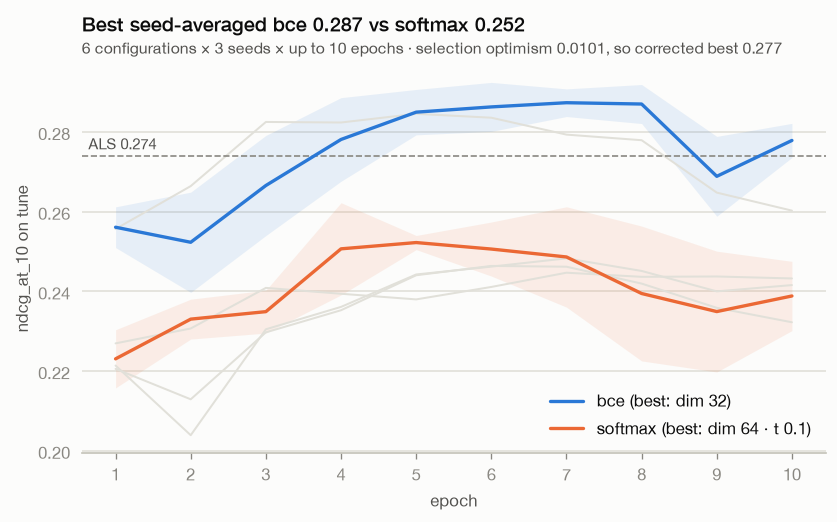

In [7]:
loss_colors = dict(zip(sorted(trials["loss"].unique()), style.SERIES, strict=False))
best_curves = set(best_per_loss.select("loss", "config").iter_rows())
fig, ax = plt.subplots(figsize=(8, 4.2))
for (loss, config), curve in trials.sort("epoch").group_by("loss", "config", maintain_order=True):
    is_best = (loss, config) in best_curves
    ax.plot(
        curve["epoch"],
        curve[METRIC],
        color=loss_colors[loss] if is_best else style.GRID,
        linewidth=style.LINE_WIDTH if is_best else 1.2,
        zorder=3 if is_best else 2,
        label=f"{loss} (best: {config})" if is_best else None,
    )
    if is_best:
        ax.fill_between(
            curve["epoch"],
            curve[METRIC] - curve["seed_sd"],
            curve[METRIC] + curve["seed_sd"],
            color=loss_colors[loss],
            alpha=style.AREA_ALPHA,
            linewidth=0,
        )
als_score = report["models"]["als"][METRIC]
ax.axhline(als_score, color=style.INK_MUTED, linewidth=1, linestyle="--")
ax.annotate(
    f"ALS {als_score:.3f}",
    (0, als_score),
    xycoords=("axes fraction", "data"),
    xytext=(4, 4),
    textcoords="offset points",
    ha="left",
    color=style.INK_SECONDARY,
    fontsize=9,
)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.set_xlabel("epoch")
ax.set_ylabel(f"{METRIC} on tune")
ax.legend(loc="lower right")
best_by_loss = dict(best_per_loss.select("loss", METRIC).iter_rows())
style.add_title(
    ax,
    "Best seed-averaged "
    + " vs ".join(f"{loss} {score:.3f}" for loss, score in sorted(best_by_loss.items())),
    f"{trials.select('loss', 'config').n_unique()} configurations × {len(search['best']['params']['seeds'])}"
    f" seeds × up to {trials['epoch'].max()} epochs · selection optimism "
    f"{search['selection_optimism']:.4f}, so corrected best {search['best_score_optimism_corrected']:.3f}",
)
save(fig, "13_two_tower_training_curves")

## 4. Accuracy vs. popularity bias, every model

A model can buy accuracy by recommending what is already popular. The x-axis is the average
popularity percentile of what each model puts in users' top 10; marker size is catalogue
coverage (share of videos that reach anyone's top 10).

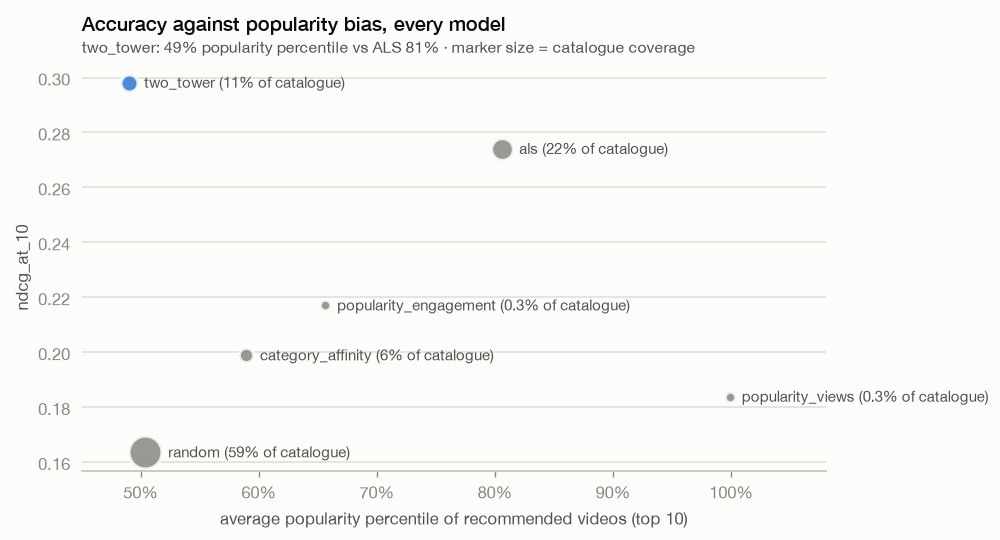

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.4))
for row in models.iter_rows(named=True):
    ax.scatter(
        [row["popularity_pct_at_10"]],
        [row[METRIC]],
        s=40 + 600 * row["coverage_at_10"],  # marker area grows with catalogue coverage
        color=emphasis(row["model"]),
        alpha=0.85,
        edgecolors=style.SURFACE,
        linewidths=2,
    )
    marker_area = 40 + 600 * row["coverage_at_10"]
    coverage = row["coverage_at_10"]
    ax.annotate(
        f"{row['model']} ({coverage:.1%} of catalogue)"
        if coverage < 0.01
        else f"{row['model']} ({coverage:.0%} of catalogue)",
        (row["popularity_pct_at_10"], row[METRIC]),
        xytext=(marker_area**0.5 / 2 + 4, -3),
        textcoords="offset points",
        color=style.INK_SECONDARY,
        fontsize=9,
    )
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlim(0.45, 1.08)
ax.set_xlabel("average popularity percentile of recommended videos (top 10)")
ax.set_ylabel(METRIC)
two_tower, als = report["models"][HIGHLIGHT], report["models"]["als"]
style.add_title(
    ax,
    "Accuracy against popularity bias, every model",
    f"two_tower: {two_tower['popularity_pct_at_10']:.0%} popularity percentile vs ALS "
    f"{als['popularity_pct_at_10']:.0%} · marker size = catalogue coverage",
)
save(fig, "14_accuracy_vs_popularity")